# Exercise 1

Create a model using K-Nearest Neigbors to perform classification using the personality dataset.

0 -'introvert'

1 - 'extrovert'

## A. Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

data = {
    "name": [
        "John",
        "Anna",
        "Mark",
        "Liza",
        "Peter"
    ],

    "Study_hours": [
        2,
        8,
        6,
        9,
        3
    ],

    "Attendance": [
        60,
        95,
        80,
        98,
        55
    ],

    "Assignments_completed": [
        3,
        10,
        8,
        10,
        4
    ],

    "Sleep_hours": [
        5,
        8,
        7,
        9,
        4
    ],

    "Previous_score": [
        50,
        90,
        75,
        95,
        45
    ],

    "Participation": [
        2,
        9,
        7,
        10,
        3
    ],

    "Performance": [
        0,
        1,
        1,
        1,
        0
    ]
}

df = pd.DataFrame(data)

## B. Load and understand the dataset

Display the first 5 rows of the dataset using `.head()`

In [2]:
print(df.head())

    name  Study_hours  Attendance  Assignments_completed  Sleep_hours  \
0   John            2          60                      3            5   
1   Anna            8          95                     10            8   
2   Mark            6          80                      8            7   
3   Liza            9          98                     10            9   
4  Peter            3          55                      4            4   

   Previous_score  Participation  Performance  
0              50              2            0  
1              90              9            1  
2              75              7            1  
3              95             10            1  
4              45              3            0  


Display the summary of all the features of the dataset using `.info()`

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   name                   5 non-null      object
 1   Study_hours            5 non-null      int64 
 2   Attendance             5 non-null      int64 
 3   Assignments_completed  5 non-null      int64 
 4   Sleep_hours            5 non-null      int64 
 5   Previous_score         5 non-null      int64 
 6   Participation          5 non-null      int64 
 7   Performance            5 non-null      int64 
dtypes: int64(7), object(1)
memory usage: 452.0+ bytes


Display the total number of samples from each label using `.value_counts()`

In [4]:
print(df["Performance"].value_counts())

Performance
1    3
0    2
Name: count, dtype: int64


Use a histogram to display the number of followers for each samples
 - The x axis should be the number of followers/friends
 - The y axis should be the number of samples in the dataset

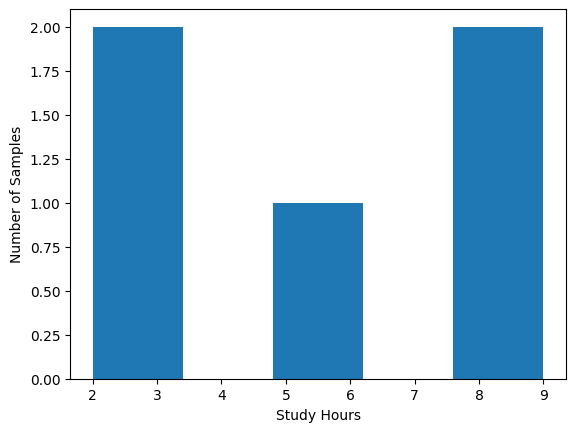

In [5]:
plt.hist(df["Study_hours"], bins=5)

plt.xlabel("Study Hours")
plt.ylabel("Number of Samples")

plt.show()

Remove the name column using `drop()` method

In [6]:
df = df.drop("name", axis=1)

## C. Split the dataset into training and test set

Convert the features into an numpy array using `.values()` and store it in a variable "X"

In [7]:
X = df.drop("Performance", axis=1).values

print(X)

[[ 2 60  3  5 50  2]
 [ 8 95 10  8 90  9]
 [ 6 80  8  7 75  7]
 [ 9 98 10  9 95 10]
 [ 3 55  4  4 45  3]]


Convert the labels into an numpy array using `.values()` and store it in a variable "y"

In [8]:
y = df["Performance"].values

print(y)

[0 1 1 1 0]


Use `train_test_split()` to split the data.

- Declare a variable `X_train` that will hold the training data
- Declare a variable `X_test` that will hold the test data
- Declare a variable `y_train` that will hold the label of the training data
- Declare a variable `y_test` that will hold the label of the test data


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4, 6)
X_test : (1, 6)
y_train: (4,)
y_test : (1,)


Display the dimensions of each variables using `.shape()`

In [10]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (4, 6)
X_test shape: (1, 6)


## D. Create the model

Use KNN as a classifier by using `KNeighborsClassifier()`

In [11]:
model = KNeighborsClassifier(n_neighbors=1)

Train the model using the `.fit()`

In [12]:
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

Test the model using the `.predict()`

In [13]:
y_pred = model.predict(X_test)

print(y_pred)

[1]


## E. Evaluate the model

Create a confusion matrix

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


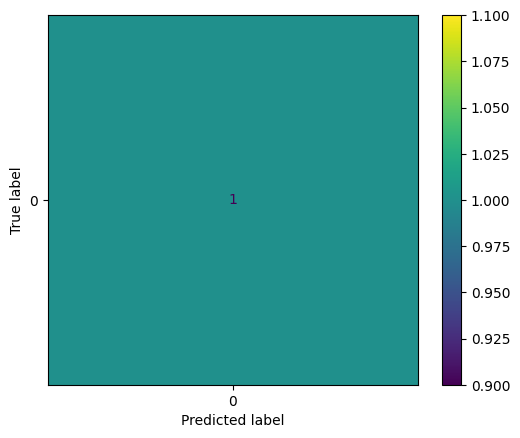

In [14]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.show()

Display the accuracy

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


Display the precision

In [16]:
print(
    "Precision:",
    precision_score(y_test, y_pred, zero_division=0)
)

Precision: 1.0


Display the recall

In [17]:
print(
    "Recall:",
    recall_score(y_test, y_pred, zero_division=0)
)

Recall: 1.0


Display the f1-score

In [18]:
print(
    "F1 Score:",
    f1_score(y_test, y_pred, zero_division=0)
)

F1 Score: 1.0


## F. Predict your own personality

Enter your own features and use the model to generate a prediction using `.predict()`

In [19]:
my_features = [[
    7,    # Study hours
    85,   # Attendance
    8,    # Assignments completed
    7,    # Sleep hours
    80,   # Previous score
    8     # Participation
]]

prediction = model.predict(my_features)

print(prediction)

if prediction[0] == 0:
    print("Fail")
else:
    print("Pass")

[1]
Pass
